In [18]:
!pip install chromadb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 3.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.9/19.9 MB 116.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 74.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.3/103.3 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.3/132.3 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.0/208.0 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 11.9 MB/s 

In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import CLIPModel,CLIPProcessor
from torch.utils.data import Dataset, DataLoader
import torch
import time
import torch.nn.functional as F
import torch.nn as nn
from PIL import Image
from IPython.display import display

import numpy as np
import transformers
import types
import glob
import os
import chromadb

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"using devices: {device}")

using devices: cuda


In [3]:
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_tokenizer = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [4]:
class SpanishCLIPAdapter(nn.Module):
    def __init__(self, vocab_size, hidden_dim=512, n_heads=8):
        super().__init__()
        self.token_embed = nn.Embedding(vocab_size, hidden_dim) #need to convert tokens to learned embedding first

        self.encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=n_heads,
            dim_feedforward=hidden_dim * 4,
            activation='gelu',
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(self.encoder_layer, num_layers=1)
        self.proj = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, input_ids):
        # input_ids: [B, 77]
        x = self.token_embed(input_ids)
        x = self.transformer(x)
        pooled = x.mean(dim=1)
        return F.layer_norm(self.proj(pooled), (pooled.size(-1),))

Sanity check: if clip tokenizer works for spanish texts and if our SpanishCLIP model correctly works in mapping our input to 512 pooled embedding size

In [5]:
test_text=["un globo flotando en el cielo"]
inputs = clip_tokenizer(text=test_text, padding='max_length', truncation=True,
                   max_length=77, return_tensors='pt')
print(inputs['input_ids'].shape)

torch.Size([1, 77])


In [6]:
#using clip toeknizer's vocab size since we using it to tokenize our spanish texts
spanish_clip = SpanishCLIPAdapter(vocab_size=clip_tokenizer.tokenizer.vocab_size).to(device)
out = spanish_clip(inputs['input_ids'].to(device))
print(out.shape)
print(clip_tokenizer.tokenizer.vocab_size)

torch.Size([1, 512])
49408


Traininig data consisting of english:spanish pairs generated by chatgpt. Around 800 entries for training and 100 entries for testing

In [8]:
text_pairs = {
    "a cat sleeping on the sofa": "un gato durmiendo en el sofá",
    "a cup of coffee on the table": "una taza de café sobre la mesa",
    "the mountain covered in snow": "la montaña cubierta de nieve",
    "a red sports car parked outside": "un coche deportivo rojo estacionado afuera",
    "children playing football": "niños jugando al fútbol",
    "a sunset over the ocean": "una puesta de sol sobre el océano",
    "a bowl of fresh fruit": "un cuenco de fruta fresca",
    "a person riding a bicycle": "una persona montando en bicicleta",
    "a dog running in the park": "un perro corriendo en el parque",
    "a busy city street at night": "una calle de ciudad concurrida por la noche",
    "a steaming bowl of soup": "un cuenco humeante de sopa",
    "a book open on a desk": "un libro abierto sobre un escritorio",
    "a plane flying above the clouds": "un avión volando sobre las nubes",
    "a bouquet of colorful flowers": "un ramo de flores coloridas",
    "a cozy cabin in the forest": "una cabaña acogedora en el bosque",
    "a smiling woman holding an umbrella": "una mujer sonriente sosteniendo un paraguas",
    "a man playing the guitar": "un hombre tocando la guitarra",
    "a chef preparing sushi": "un chef preparando sushi",
    "a lighthouse near the sea": "un faro cerca del mar",
    "a train passing through the countryside": "un tren pasando por el campo",
    "a person reading under a tree": "una persona leyendo bajo un árbol",
    "a glass of red wine": "una copa de vino tinto",
    "a soccer stadium full of fans": "un estadio de fútbol lleno de aficionados",
    "a forest path covered in leaves": "un sendero del bosque cubierto de hojas",
    "a horse running on the beach": "un caballo corriendo en la playa",
    "a plate of spaghetti": "un plato de espaguetis",
    "a candle lighting a dark room": "una vela iluminando una habitación oscura",
    "a person painting a landscape": "una persona pintando un paisaje",
    "a couple walking in the rain": "una pareja caminando bajo la lluvia",
    "a baby laughing": "un bebé riendo",
    "a street market with fresh vegetables": "un mercado callejero con verduras frescas",
    "a man wearing sunglasses": "un hombre con gafas de sol",
    "a smartphone on a wooden table": "un teléfono inteligente sobre una mesa de madera",
    "a dolphin jumping out of the water": "un delfín saltando fuera del agua",
    "a mountain road full of curves": "una carretera de montaña llena de curvas",
    "a violin resting on a chair": "un violín descansando en una silla",
    "a plate of tacos": "un plato de tacos",
    "a woman drinking tea": "una mujer bebiendo té",
    "a lion resting in the savanna": "un león descansando en la sabana",
    "a computer with colorful lights": "un ordenador con luces de colores",
    "a painter mixing colors": "un pintor mezclando colores",
    "a person climbing a mountain": "una persona escalando una montaña",
    "a coffee shop on a corner": "una cafetería en una esquina",
    "a small boat on the lake": "un pequeño barco en el lago",
    "a baker making bread": "un panadero haciendo pan",
    "a robot cleaning the floor": "un robot limpiando el suelo",
    "a car driving through the desert": "un coche conduciendo por el desierto",
    "a butterfly sitting on a flower": "una mariposa posada sobre una flor",
    "a beach full of umbrellas": "una playa llena de sombrillas",
    "a waiter serving food": "un camarero sirviendo comida",
    "a plate of sushi": "un plato de sushi",
    "a bowl of ramen": "un cuenco de ramen",
    "freshly baked bread": "pan recién horneado",
    "a slice of chocolate cake": "una porción de pastel de chocolate",
    "a basket of strawberries": "una cesta de fresas",
    "a pizza with cheese and olives": "una pizza con queso y aceitunas",
    "grilled salmon with lemon": "salmón a la parrilla con limón",
    "a glass of orange juice": "un vaso de jugo de naranja",
    "pasta with tomato sauce": "pasta con salsa de tomate",
    "a table full of desserts": "una mesa llena de postres",
    "a chef cutting vegetables": "un chef cortando verduras",
    "a cup of green tea": "una taza de té verde",
    "a sandwich with ham and cheese": "un sándwich con jamón y queso",
    "a bowl of cereal with milk": "un cuenco de cereales con leche",
    "spices on a wooden table": "especias sobre una mesa de madera",
    "a pot of hot soup": "una olla de sopa caliente",
    "a croissant and coffee": "un croissant y café",
    "a tray of sushi rolls": "una bandeja de rollos de sushi",
    "a salad with avocado": "una ensalada con aguacate",
    "a taco stand in the street": "un puesto de tacos en la calle",
    "a teacher writing on the board": "una maestra escribiendo en la pizarra",
    "a doctor examining a patient": "un médico examinando a un paciente",
    "a runner crossing the finish line": "un corredor cruzando la línea de meta",
    "a firefighter holding a hose": "un bombero sosteniendo una manguera",
    "a photographer taking pictures": "un fotógrafo tomando fotos",
    "a person meditating by the lake": "una persona meditando junto al lago",
    "a dancer performing on stage": "una bailarina actuando en el escenario",
    "a farmer harvesting wheat": "un agricultor cosechando trigo",
    "a mechanic repairing a car": "un mecánico reparando un coche",
    "a scientist looking into a microscope": "una científica mirando por un microscopio",
    "a barber cutting hair": "un barbero cortando el cabello",
    "a construction worker with a helmet": "un obrero con casco",
    "a person playing the piano": "una persona tocando el piano",
    "a singer performing with a microphone": "una cantante actuando con un micrófono",
    "a student reading a book": "un estudiante leyendo un libro",
    "a child drawing with crayons": "un niño dibujando con crayones",
    "a group of friends laughing": "un grupo de amigos riendo",
    "a person doing yoga": "una persona haciendo yoga",
    "a nurse giving a vaccine": "una enfermera poniendo una vacuna",
    "a man working on a laptop": "un hombre trabajando en un portátil",
    "a waterfall in the jungle": "una cascada en la selva",
    "a snowy mountain peak": "un pico de montaña nevado",
    "a river flowing through the valley": "un río que fluye por el valle",
    "a desert with sand dunes": "un desierto con dunas de arena",
    "a forest in autumn": "un bosque en otoño",
    "waves crashing on the rocks": "olas rompiendo contra las rocas",
    "a rainbow after the storm": "un arco iris después de la tormenta",
    "a night sky full of stars": "un cielo nocturno lleno de estrellas",
    "a calm lake at sunrise": "un lago tranquilo al amanecer",
    "a volcano erupting": "un volcán en erupción",
    "flowers blooming in spring": "flores floreciendo en primavera",
    "a path through the forest": "un sendero a través del bosque",
    "a glacier melting under the sun": "un glaciar derritiéndose bajo el sol",
    "a canyon with red rocks": "un cañón con rocas rojas",
    "a meadow full of daisies": "un prado lleno de margaritas",
    "a lighthouse on the cliff": "un faro en el acantilado",
    "a foggy morning in the mountains": "una mañana con niebla en las montañas",
    "a palm tree on the beach": "una palmera en la playa",
    "a field of sunflowers": "un campo de girasoles",
    "a frozen lake in winter": "un lago congelado en invierno",
    "a vintage camera on a shelf": "una cámara vintage en un estante",
    "a laptop on a wooden desk": "un portátil sobre un escritorio de madera",
    "a smartphone charging": "un teléfono móvil cargando",
    "a pair of headphones on a table": "unos auriculares sobre una mesa",
    "a glowing neon sign": "un cartel de neón brillante",
    "a robot holding a flower": "un robot sosteniendo una flor",
    "a wristwatch made of metal": "un reloj de pulsera de metal",
    "a bookshelf full of books": "una estantería llena de libros",
    "a glass bottle with water": "una botella de vidrio con agua",
    "a lantern lighting the night": "una linterna iluminando la noche",
    "a television in the living room": "un televisor en la sala de estar",
    "a drone flying over a field": "un dron volando sobre un campo",
    "a stack of colorful pillows": "una pila de cojines coloridos",
    "a typewriter with paper": "una máquina de escribir con papel",
    "a 3d printer creating a model": "una impresora 3d creando un modelo",
    "a tablet with a stylus": "una tableta con un lápiz óptico",
    "a pair of glasses on a book": "unas gafas sobre un libro",
    "a vinyl record on a turntable": "un disco de vinilo en un tocadiscos",
    "a candle on a windowsill": "una vela en el alféizar de una ventana",
    "a compass on a map": "una brújula sobre un mapa",
    "a dog catching a frisbee": "un perro atrapando un frisbee",
    "a cat playing with yarn": "un gato jugando con hilo",
    "a horse running in a field": "un caballo corriendo en un campo",
    "a bird sitting on a branch": "un pájaro posado en una rama",
    "a fish swimming in a tank": "un pez nadando en un acuario",
    "a cow grazing in a meadow": "una vaca pastando en un prado",
    "a butterfly landing on a flower": "una mariposa posándose en una flor",
    "a bee collecting nectar": "una abeja recolectando néctar",
    "a lion roaring loudly": "un león rugiendo fuertemente",
    "a penguin walking on ice": "un pingüino caminando sobre el hielo",
    "a turtle swimming in the ocean": "una tortuga nadando en el océano",
    "a parrot with colorful feathers": "un loro con plumas coloridas",
    "a fox hiding behind a tree": "un zorro escondido detrás de un árbol",
    "a squirrel eating a nut": "una ardilla comiendo una nuez",
    "a frog on a leaf": "una rana sobre una hoja",
    "a dog sleeping under a tree": "un perro durmiendo bajo un árbol",
    "a camel walking in the desert": "un camello caminando en el desierto",
    "a bear fishing in a river": "un oso pescando en un río",
    "a cat looking out the window": "un gato mirando por la ventana",
    "a rabbit jumping through the grass": "un conejo saltando entre la hierba",
    "a person smiling happily": "una persona sonriendo felizmente",
    "a man crying in the rain": "un hombre llorando bajo la lluvia",
    "a woman surprised by a gift": "una mujer sorprendida por un regalo",
    "a child laughing loudly": "un niño riendo a carcajadas",
    "a person showing anger": "una persona mostrando enfado",
    "a group celebrating victory": "un grupo celebrando la victoria",
    "a couple hugging each other": "una pareja abrazándose",
    "a person looking worried": "una persona con expresión de preocupación",
    "friends taking a selfie": "amigos tomándose una selfie",
    "a person clapping hands": "una persona aplaudiendo",
    "a person looking at a painting": "una persona mirando una pintura",
    "a crowd cheering at a concert": "una multitud animando en un concierto",
    "a person yawning": "una persona bostezando",
    "a dancer smiling on stage": "una bailarina sonriendo en el escenario",
    "a baby reaching out to touch something": "un bebé extendiendo la mano para tocar algo",
    "a man thinking deeply": "un hombre pensando profundamente",
    "a woman laughing at a joke": "una mujer riendo de un chiste",
    "a child showing excitement": "un niño mostrando entusiasmo",
    "a person meditating peacefully": "una persona meditando en paz",
    "a group enjoying fireworks": "un grupo disfrutando de fuegos artificiales",
    "a street in paris at night": "una calle en parís por la noche",
    "a market full of people": "un mercado lleno de gente",
    "a park with a fountain": "un parque con una fuente",
    "a subway station with lights": "una estación de metro con luces",
    "a quiet village in the hills": "un pueblo tranquilo en las colinas",
    "a busy airport terminal": "una terminal de aeropuerto concurrida",
    "a restaurant by the sea": "un restaurante junto al mar",
    "a library with tall shelves": "una biblioteca con estanterías altas",
    "a stadium full of fans": "un estadio lleno de aficionados",
    "a bridge over the river": "un puente sobre el río",
    "a school classroom with desks": "un aula escolar con escritorios",
    "a museum with ancient statues": "un museo con estatuas antiguas",
    "a hospital corridor": "un pasillo de hospital",
    "a factory producing cars": "una fábrica produciendo coches",
    "a small house with a red roof": "una casa pequeña con techo rojo",
    "a castle surrounded by trees": "un castillo rodeado de árboles",
    "a bus driving through the city": "un autobús conduciendo por la ciudad",
    "a train station with people waiting": "una estación de tren con gente esperando",
    "a cafe on a corner": "una cafetería en una esquina",
    "a boat in the harbor": "un barco en el puerto",
    "a person brushing their teeth": "una persona cepillándose los dientes",
    "a woman tying her shoes": "una mujer atándose los zapatos",
    "a man reading the newspaper": "un hombre leyendo el periódico",
    "a person opening a door": "una persona abriendo una puerta",
    "a student writing notes": "un estudiante tomando apuntes",
    "a person cooking breakfast": "una persona cocinando el desayuno",
    "a mother holding her baby": "una madre sosteniendo a su bebé",
    "a person pouring coffee": "una persona sirviendo café",
    "a person watching television": "una persona viendo la televisión",
    "a family having dinner": "una familia cenando junta",
    "a person washing dishes": "una persona lavando los platos",
    "a man riding a motorcycle": "un hombre montando una motocicleta",
    "a woman talking on the phone": "una mujer hablando por teléfono",
    "a person ironing clothes": "una persona planchando ropa",
    "a child playing with blocks": "un niño jugando con bloques",
    "a person unlocking a bicycle": "una persona desbloqueando una bicicleta",
    "a person lighting a candle": "una persona encendiendo una vela",
    "a person writing a letter": "una persona escribiendo una carta",
    "a man drinking water": "un hombre bebiendo agua",
    "a person folding laundry": "una persona doblando la ropa",
    "A cat sitting on the couch": "Un gato sentado en el sofá",
    "A red car driving down the street": "Un coche rojo conduciendo por la calle",
    "A man riding a bicycle in the park": "Un hombre montando una bicicleta en el parque",
    "A cup of coffee on the table": "Una taza de café sobre la mesa",
    "A woman reading a book": "Una mujer leyendo un libro",
    "A dog playing with a ball": "Un perro jugando con una pelota",
    "A group of people walking in the city": "Un grupo de personas caminando por la ciudad",
    "A mountain covered in snow": "Una montaña cubierta de nieve",
    "A plate of fresh fruit": "Un plato de fruta fresca",
    "A beach with clear blue water": "Una playa con agua azul clara",
    "A child drawing with crayons": "Un niño dibujando con crayones",
    "A plane flying in the sky": "Un avión volando en el cielo",
    "A sunset over the ocean": "Una puesta de sol sobre el océano",
    "A person working on a laptop": "Una persona trabajando en una computadora portátil",
    "A cup of tea next to a book": "Una taza de té junto a un libro",
    "A soccer player kicking a ball": "Un jugador de fútbol pateando un balón",
    "A busy street at night": "Una calle concurrida por la noche",
    "A forest with tall green trees": "Un bosque con árboles verdes y altos",
    "A chef preparing a meal": "Un chef preparando una comida",
    "A horse running through a field": "Un caballo corriendo por un campo",
    "A musician playing guitar on stage": "Un músico tocando la guitarra en el escenario",
    "A woman holding an umbrella in the rain": "Una mujer sosteniendo un paraguas bajo la lluvia",
    "A man wearing a hat and sunglasses": "Un hombre con sombrero y gafas de sol",
    "A child eating ice cream": "Un niño comiendo helado",
    "A bridge over a river": "Un puente sobre un río",
    "A smartphone on a wooden table": "Un teléfono inteligente sobre una mesa de madera",
    "A cat looking out the window": "Un gato mirando por la ventana",
    "A bus arriving at the station": "Un autobús llegando a la estación",
    "A person swimming in a pool": "Una persona nadando en una piscina",
    "A coffee shop on the corner": "Una cafetería en la esquina",
    "A lighthouse by the sea": "Un faro junto al mar",
    "A snowy path through the woods": "Un camino nevado a través del bosque",
    "A child playing with blocks": "Un niño jugando con bloques",
    "A train passing through the countryside": "Un tren pasando por el campo",
    "A bowl of fresh salad": "Un cuenco de ensalada fresca",
    "A man reading the newspaper": "Un hombre leyendo el periódico",
    "A city skyline at night": "El horizonte de la ciudad por la noche",
    "A woman taking a photograph": "Una mujer tomando una fotografía",
    "A person hiking in the mountains": "Una persona haciendo senderismo en las montañas",
    "A candle burning in the dark": "Una vela encendida en la oscuridad",
    "A girl brushing her hair": "Una chica cepillándose el cabello",
    "A table set for dinner": "Una mesa puesta para la cena",
    "A person painting on a canvas": "Una persona pintando sobre un lienzo",
    "A car parked near a tree": "Un coche estacionado cerca de un árbol",
    "A man cooking in the kitchen": "Un hombre cocinando en la cocina",
    "A flock of birds flying together": "Una bandada de pájaros volando junta",
    "A person running along the beach": "Una persona corriendo por la playa",
    "A woman drinking water after exercise": "Una mujer bebiendo agua después de hacer ejercicio",
    "A street full of colorful houses": "Una calle llena de casas coloridas",
    "A computer screen showing code": "Una pantalla de computadora mostrando código",
    "A baby sleeping peacefully": "Un bebé durmiendo tranquilamente",
    "A man holding a camera": "Un hombre sosteniendo una cámara",
    "A woman wearing a red dress": "Una mujer con un vestido rojo",
    "A dog sleeping on the floor": "Un perro durmiendo en el suelo",
    "A person reading under a tree": "Una persona leyendo bajo un árbol",
    "A train arriving at the platform": "Un tren llegando al andén",
    "A child running through the grass": "Un niño corriendo por el césped",
    "A boat floating on the lake": "Un barco flotando en el lago",
    "A cat playing with yarn": "Un gato jugando con hilo",
    "A group of friends taking a selfie": "Un grupo de amigos tomándose una selfie",
    "A bird sitting on a branch": "Un pájaro posado en una rama",
    "A person cooking eggs in a pan": "Una persona cocinando huevos en una sartén",
    "A street full of people and cars": "Una calle llena de gente y coches",
    "A boy jumping into the pool": "Un niño saltando a la piscina",
    "A mountain reflected in the water": "Una montaña reflejada en el agua",
    "A woman smiling at the camera": "Una mujer sonriendo a la cámara",
    "A man painting a wall": "Un hombre pintando una pared",
    "A bicycle leaning against a fence": "Una bicicleta apoyada contra una cerca",
    "A person tying their shoes": "Una persona atándose los zapatos",
    "A baby laughing loudly": "Un bebé riendo a carcajadas",
    "A person skiing down a slope": "Una persona esquiando por una pendiente",
    "A truck driving on a highway": "Un camión conduciendo por una autopista",
    "A plate of pasta with cheese": "Un plato de pasta con queso",
    "A woman cutting vegetables": "Una mujer cortando verduras",
    "A man fishing by the river": "Un hombre pescando junto al río",
    "A cat hiding behind a curtain": "Un gato escondido detrás de una cortina",
    "A person standing on a rock by the sea": "Una persona de pie sobre una roca junto al mar",
    "A soccer team celebrating a goal": "Un equipo de fútbol celebrando un gol",
    "A couple walking hand in hand": "Una pareja caminando de la mano",
    "A glass of orange juice on the table": "Un vaso de jugo de naranja sobre la mesa",
    "A woman climbing a mountain": "Una mujer escalando una montaña",
    "A child building a sandcastle": "Un niño construyendo un castillo de arena",
    "A bird flying over the ocean": "Un pájaro volando sobre el océano",
    "A man shaving in front of a mirror": "Un hombre afeitándose frente a un espejo",
    "A group of dancers performing on stage": "Un grupo de bailarines actuando en el escenario",
    "A laptop open on a desk": "Un portátil abierto sobre un escritorio",
    "A person walking a dog in the park": "Una persona paseando a un perro en el parque",
    "A plate of pancakes with syrup": "Un plato de panqueques con jarabe",
    "A person waiting at a bus stop": "Una persona esperando en una parada de autobús",
    "A woman looking out the window": "Una mujer mirando por la ventana",
    "A cup of hot chocolate with marshmallows": "Una taza de chocolate caliente con malvaviscos",
    "A tennis player hitting the ball": "Un jugador de tenis golpeando la pelota",
    "A man reading a map": "Un hombre leyendo un mapa",
    "A baker putting bread in the oven": "Un panadero metiendo pan al horno",
    "A classroom full of students": "Un aula llena de estudiantes",
    "A person holding a bunch of flowers": "Una persona sosteniendo un ramo de flores",
    "A dog jumping over a fence": "Un perro saltando sobre una cerca",
    "A firefighter spraying water on flames": "Un bombero rociando agua sobre las llamas",
    "A skateboarder performing a trick": "Un patinador realizando un truco",
    "A person writing in a notebook": "Una persona escribiendo en un cuaderno",
    "A rainbow appearing after the rain": "Un arcoíris apareciendo después de la lluvia",
    "A man sitting by a campfire": "Un hombre sentado junto a una fogata",
    "a cat sleeping on the sofa": "un gato durmiendo en el sofá",
    "a cup of coffee on the table": "una taza de café sobre la mesa",
    "the mountain covered in snow": "la montaña cubierta de nieve",
    "a red sports car parked outside": "un coche deportivo rojo estacionado afuera",
    "children playing football": "niños jugando al fútbol",
    "a dog running in the park": "un perro corriendo en el parque",
    "a woman reading a book": "una mujer leyendo un libro",
    "the sun setting over the ocean": "el sol poniéndose sobre el océano",
    "a man riding a bicycle": "un hombre montando una bicicleta",
    "birds flying in the sky": "pájaros volando en el cielo",
    "a plate of fresh fruit": "un plato de fruta fresca",
    "a train arriving at the station": "un tren llegando a la estación",
    "a family having dinner together": "una familia cenando junta",
    "a girl drawing with crayons": "una niña dibujando con crayones",
    "the city lights at night": "las luces de la ciudad por la noche",
    "a fisherman on a small boat": "un pescador en un bote pequeño",
    "a baby sleeping peacefully": "un bebé durmiendo plácidamente",
    "a waiter serving food": "un camarero sirviendo comida",
    "flowers blooming in the garden": "flores floreciendo en el jardín",
    "a boy playing the guitar": "un niño tocando la guitarra",
    "a teacher writing on the board": "una maestra escribiendo en la pizarra",
    "the river flowing through the valley": "el río fluyendo por el valle",
    "a couple walking on the beach": "una pareja caminando por la playa",
    "an airplane flying above the clouds": "un avión volando sobre las nubes",
    "a chef cooking in the kitchen": "un chef cocinando en la cocina",
    "a laptop on the desk": "un portátil sobre el escritorio",
    "a dog barking at the mailman": "un perro ladrando al cartero",
    "kids riding their bikes": "niños montando sus bicicletas",
    "a rainbow after the rain": "un arcoíris después de la lluvia",
    "a person painting a landscape": "una persona pintando un paisaje",
    "the moon shining brightly": "la luna brillando intensamente",
    "a bird sitting on a branch": "un pájaro sentado en una rama",
    "a car driving through the city": "un coche conduciendo por la ciudad",
    "a man drinking a glass of water": "un hombre bebiendo un vaso de agua",
    "students studying in the library": "estudiantes estudiando en la biblioteca",
    "a girl holding a red balloon": "una niña sosteniendo un globo rojo",
    "a baker making bread": "un panadero haciendo pan",
    "people waiting at the bus stop": "personas esperando en la parada de autobús",
    "a storm approaching the coast": "una tormenta acercándose a la costa",
    "a doctor examining a patient": "un médico examinando a un paciente",
    "a child playing with a puppy": "un niño jugando con un cachorro",
    "a cyclist on a country road": "un ciclista en una carretera rural",
    "the stars twinkling at night": "las estrellas brillando por la noche",
    "a woman talking on the phone": "una mujer hablando por teléfono",
    "a man reading the newspaper": "un hombre leyendo el periódico",
    "a cat sitting on the windowsill": "un gato sentado en el alféizar",
    "a swimmer in the pool": "un nadador en la piscina",
    "a couple dancing in the rain": "una pareja bailando bajo la lluvia",
    "a photographer taking pictures": "un fotógrafo tomando fotos",
    "a bus driving down the street": "un autobús conduciendo por la calle",
    "a child drawing on the sidewalk": "un niño dibujando en la acera",
    "a cat sleeping on the sofa": "un gato durmiendo en el sofá",
    "a dog running in the park": "un perro corriendo en el parque",
    "a woman reading a book": "una mujer leyendo un libro",
    "a man riding a bicycle": "un hombre montando una bicicleta",
    "children playing football": "niños jugando al fútbol",
    "a red car driving fast": "un coche rojo conduciendo rápido",
    "birds flying in the sky": "pájaros volando en el cielo",
    "a cup of coffee on the table": "una taza de café sobre la mesa",
    "a child drawing with crayons": "un niño dibujando con crayones",
    "a baby sleeping peacefully": "un bebé durmiendo plácidamente",
    "a family having dinner together": "una familia cenando junta",
    "the mountain covered in snow": "la montaña cubierta de nieve",
    "a beach full of shells": "una playa llena de conchas",
    "a woman holding a bouquet of flowers": "una mujer sosteniendo un ramo de flores",
    "a boy flying a kite": "un niño volando una cometa",
    "a chef cooking pasta": "un chef cocinando pasta",
    "the city lights at night": "las luces de la ciudad por la noche",
    "a train leaving the station": "un tren saliendo de la estación",
    "a student taking notes in class": "un estudiante tomando apuntes en clase",
    "a man playing the piano": "un hombre tocando el piano",
    "a couple walking hand in hand": "una pareja caminando de la mano",
    "a painter working on a portrait": "un pintor trabajando en un retrato",
    "a girl holding a red balloon": "una niña sosteniendo un globo rojo",
    "a cat sitting on the windowsill": "un gato sentado en el alféizar",
    "a doctor examining a patient": "un médico examinando a un paciente",
    "a fisherman on a boat": "un pescador en un bote",
    "the sun setting behind the hills": "el sol poniéndose detrás de las colinas",
    "a cyclist on a country road": "un ciclista en una carretera rural",
    "a baker making bread": "un panadero haciendo pan",
    "a person painting a landscape": "una persona pintando un paisaje",
    "a girl dancing in the garden": "una niña bailando en el jardín",
    "the river flowing through the valley": "el río fluyendo por el valle",
    "a boy reading under a tree": "un niño leyendo bajo un árbol",
    "a waiter serving drinks": "un camarero sirviendo bebidas",
    "a car parked in front of a house": "un coche aparcado frente a una casa",
    "flowers blooming in the garden": "flores floreciendo en el jardín",
    "a man drinking tea": "un hombre bebiendo té",
    "a teacher writing on the blackboard": "una maestra escribiendo en la pizarra",
    "a dog barking at a stranger": "un perro ladrando a un extraño",
    "a child holding an ice cream": "un niño sosteniendo un helado",
    "a bird sitting on a branch": "un pájaro sentado en una rama",
    "a swimmer in the pool": "un nadador en la piscina",
    "a couple dancing under the stars": "una pareja bailando bajo las estrellas",
    "a woman talking on the phone": "una mujer hablando por teléfono",
    "a man reading the newspaper": "un hombre leyendo el periódico",
    "a rainbow after the storm": "un arcoíris después de la tormenta",
    "a girl playing the violin": "una niña tocando el violín",
    "a cat chasing a butterfly": "un gato persiguiendo una mariposa",
    "a group of friends laughing": "un grupo de amigos riendo",
    "a plane flying above the clouds": "un avión volando sobre las nubes",
    "a farmer feeding chickens": "un granjero alimentando gallinas",
    "a child jumping into a puddle": "un niño saltando en un charco",
    "a mountain reflected in the lake": "una montaña reflejada en el lago",
    "a man tying his shoelaces": "un hombre atándose los cordones",
    "the moon shining brightly": "la luna brillando intensamente",
    "a boy playing with his dog": "un niño jugando con su perro",
    "a woman writing in her journal": "una mujer escribiendo en su diario",
    "a car crossing a bridge": "un coche cruzando un puente",
    "a girl brushing her hair": "una niña cepillándose el pelo",
    "a man climbing a ladder": "un hombre subiendo una escalera",
    "a couple looking at the stars": "una pareja mirando las estrellas",
    "a dog sleeping in its bed": "un perro durmiendo en su cama",
    "a teacher helping a student": "una maestra ayudando a un estudiante",
    "a photographer taking pictures": "un fotógrafo tomando fotos",
    "a boy building a sandcastle": "un niño construyendo un castillo de arena",
    "a woman jogging in the park": "una mujer corriendo en el parque",
    "a waiter carrying plates": "un camarero llevando platos",
    "a man repairing a car": "un hombre reparando un coche",
    "a girl watering the plants": "una niña regando las plantas",
    "a dog fetching a stick": "un perro trayendo un palo",
    "a couple sitting on a bench": "una pareja sentada en un banco",
    "children drawing with chalk": "niños dibujando con tiza",
    "a man holding an umbrella": "un hombre sosteniendo un paraguas",
    "a woman baking a cake": "una mujer horneando un pastel",
    "the waves crashing on the rocks": "las olas rompiendo en las rocas",
    "a person jogging along the river": "una persona corriendo junto al río",
    "a child playing with blocks": "un niño jugando con bloques",
    "a man fixing a bicycle": "un hombre arreglando una bicicleta",
    "a woman standing by the window": "una mujer de pie junto a la ventana",
    "a cat hiding behind a curtain": "un gato escondido detrás de una cortina",
    "a fisherman casting a net": "un pescador lanzando una red",
    "a boy wearing a hat": "un niño con un sombrero",
    "a man reading on a bench": "un hombre leyendo en un banco",
    "a woman sipping tea": "una mujer sorbiendo té",
    "a dog digging a hole": "un perro cavando un hoyo",
    "a car driving through the tunnel": "un coche pasando por el túnel",
    "a baker decorating cupcakes": "un panadero decorando magdalenas",
    "a student studying late at night": "un estudiante estudiando hasta tarde",
    "a bird drinking water": "un pájaro bebiendo agua",
    "a girl painting a flower": "una niña pintando una flor",
    "a boy running down the hill": "un niño corriendo colina abajo",
    "a woman arranging flowers": "una mujer arreglando flores",
    "a man polishing his shoes": "un hombre puliendo sus zapatos",
    "a child climbing a tree": "un niño trepando un árbol",
    "a dog catching a ball": "un perro atrapando una pelota",
    "a couple taking a walk": "una pareja dando un paseo",
    "the wind blowing through the trees": "el viento soplando entre los árboles",
    "a person cleaning the floor": "una persona limpiando el suelo",
    "a man driving a truck": "un hombre conduciendo un camión",
    "a woman folding clothes": "una mujer doblando ropa",
    "a boy watching television": "un niño viendo la televisión",
    "a bird building a nest": "un pájaro construyendo un nido",
    "a woman playing the piano": "una mujer tocando el piano",
    "a man swimming in the ocean": "un hombre nadando en el océano",
    "a child eating breakfast": "un niño desayunando",
    "a woman feeding her cat": "una mujer alimentando a su gato",
    "a man washing his car": "un hombre lavando su coche",
    "a teacher reading to the class": "una maestra leyendo a la clase",
    "a woman holding a baby": "una mujer sosteniendo un bebé",
    "a boy throwing a snowball": "un niño lanzando una bola de nieve",
    "a girl wearing a red dress": "una niña con un vestido rojo",
    "a man hiking in the forest": "un hombre haciendo senderismo en el bosque",
    "a cat stretching on the rug": "un gato estirándose en la alfombra",
    "a person lighting a candle": "una persona encendiendo una vela",
    "a woman shopping for clothes": "una mujer comprando ropa",
    "a man buying groceries": "un hombre comprando comestibles",
    "a child riding a tricycle": "un niño montando un triciclo",
    "a woman brushing her teeth": "una mujer cepillándose los dientes",
    "a man shaving his beard": "un hombre afeitándose la barba",
    "a bird singing in the morning": "un pájaro cantando por la mañana",
    "a cat drinking milk": "un gato bebiendo leche",
    "a person opening a gift": "una persona abriendo un regalo",
    "a man standing in the rain": "un hombre de pie bajo la lluvia",
    "a woman wearing sunglasses": "una mujer con gafas de sol",
    "a child blowing bubbles": "un niño soplando burbujas",
    "a girl skipping rope": "una niña saltando la cuerda",
    "a man eating lunch": "un hombre almorzando",
    "a woman cutting vegetables": "una mujer cortando verduras",
    "a boy catching butterflies": "un niño atrapando mariposas",
    "a person reading a map": "una persona leyendo un mapa",
    "a man sitting on the grass": "un hombre sentado en el césped",
    "a woman tying her hair": "una mujer atándose el pelo",
    "a child hugging a teddy bear": "un niño abrazando un oso de peluche",
    "a man playing chess": "un hombre jugando al ajedrez",
    "a dog running after a frisbee": "un perro corriendo tras un frisbee",
    "a woman knitting a sweater": "una mujer tejiendo un suéter",
    "a man opening a door": "un hombre abriendo una puerta",
    "a child eating an apple": "un niño comiendo una manzana",
    "a girl holding a doll": "una niña sosteniendo una muñeca",
    "a man pouring coffee": "un hombre sirviendo café",
    "a woman carrying groceries": "una mujer cargando las compras",
    "a person waiting at the bus stop": "una persona esperando en la parada de autobús",
    "a dog barking loudly": "un perro ladrando fuerte",
    "a cat jumping off the table": "un gato saltando de la mesa",
    "a boy blowing out candles": "un niño soplando las velas",
    "a woman wrapping a present": "una mujer envolviendo un regalo",
    "a man sitting by the fireplace": "un hombre sentado junto a la chimenea",
    "a child building with blocks": "un niño construyendo con bloques",
    "a girl looking out the window": "una niña mirando por la ventana",
    "a man holding a camera": "un hombre sosteniendo una cámara",
    "a woman opening a book": "una mujer abriendo un libro",
    "a child petting a cat": "un niño acariciando un gato",
    "a boy climbing a rock wall": "un niño escalando una pared de roca",
    "a woman holding an umbrella": "una mujer sosteniendo un paraguas",
    "a man jogging in the rain": "un hombre corriendo bajo la lluvia",
    "a dog running on the beach": "un perro corriendo por la playa",
    "a bird flying over the forest": "un pájaro volando sobre el bosque",
    "a man closing a window": "un hombre cerrando una ventana",
    "a woman lighting a lamp": "una mujer encendiendo una lámpara",
    "a child sleeping with a toy": "un niño durmiendo con un juguete",
    "a man painting a fence": "un hombre pintando una cerca",
    "a woman writing a letter": "una mujer escribiendo una carta",
    "a cat walking across the street": "un gato cruzando la calle",
    "a boy playing video games": "un niño jugando videojuegos",
    "a girl feeding ducks": "una niña alimentando patos",
    "a man listening to music": "un hombre escuchando música",
    "a woman watching a movie": "una mujer viendo una película",
    "a person opening a window": "una persona abriendo una ventana",
    "a child running through a field": "un niño corriendo por un campo",
    "a man fishing by the lake": "un hombre pescando junto al lago",
    "a woman driving a car": "una mujer conduciendo un coche",
    "a dog sleeping by the fire": "un perro durmiendo junto al fuego",
    "a cat curled up on a chair": "un gato acurrucado en una silla",
    "a man walking his dog": "un hombre paseando a su perro",
    "a woman picking apples": "una mujer recogiendo manzanas",
    "a child wearing a raincoat": "un niño con un impermeable",
    "a boy helping his father": "un niño ayudando a su padre",
    "a girl coloring a picture": "una niña coloreando un dibujo",
    "a woman cleaning a window": "una mujer limpiando una ventana",
    "a man reading a magazine": "un hombre leyendo una revista",
    "a dog looking out the window": "un perro mirando por la ventana",
    "a bird sitting on a fence": "un pájaro posado en una cerca",
    "a man cooking dinner": "un hombre cocinando la cena",
    "a woman drinking coffee": "una mujer bebiendo café",
    "a child playing in the sand": "un niño jugando en la arena",
    "a cat licking its paw": "un gato lamiéndose la pata",
    "a person jogging on the beach": "una persona corriendo por la playa",
    "a man watering the garden": "un hombre regando el jardín",
    "a woman cutting paper": "una mujer cortando papel",
    "a child eating ice cream": "un niño comiendo helado",
    "a boy running with a dog": "un niño corriendo con un perro",
    "a girl holding flowers": "una niña sosteniendo flores",
    "a man repairing a fence": "un hombre reparando una cerca",
    "a woman taking a picture": "una mujer tomando una foto",
    "a person sitting under a tree": "una persona sentada bajo un árbol",
    "a cat lying in the sun": "un gato acostado al sol",
    "a bird flying near the water": "un pájaro volando cerca del agua",
    "a dog standing in the yard": "un perro de pie en el patio",
    "a man carrying a box": "un hombre cargando una caja",
    "a woman holding a book": "una mujer sosteniendo un libro",
    "a child smiling at the camera": "un niño sonriendo a la cámara",
    "a girl jumping rope": "una niña saltando la cuerda",
    "a man drinking coffee": "un hombre bebiendo café",
    "a woman reading on a bench": "una mujer leyendo en un banco",
    "a dog wagging its tail": "un perro moviendo la cola",
    "a cat climbing a tree": "un gato trepando un árbol",
    "a boy eating a sandwich": "un niño comiendo un sándwich",
    "a girl sitting on the grass": "una niña sentada en el césped",
    "a man stretching his arms": "un hombre estirando los brazos",
    "a woman tying her shoes": "una mujer atándose los zapatos",
    "a bird landing on a roof": "un pájaro aterrizando en un tejado",
    "a dog chewing a bone": "un perro masticando un hueso",
    "a cat looking at a bird": "un gato mirando a un pájaro",
    "a man opening a bottle": "un hombre abriendo una botella",
    "a woman putting on makeup": "una mujer maquillándose",
    "a child laughing with joy": "un niño riendo de alegría",
    "a person climbing stairs": "una persona subiendo escaleras",
    "a man standing by a river": "un hombre de pie junto a un río",
    "a woman walking through a market": "una mujer caminando por un mercado",
    "a child chasing a ball": "un niño persiguiendo una pelota",
    "a dog running in circles": "un perro corriendo en círculos",
    "a cat sleeping on a cushion": "un gato durmiendo en un cojín",
    "a boy holding a soccer ball": "un niño sosteniendo un balón de fútbol",
    "a girl drawing a picture": "una niña dibujando un cuadro",
    "a man watching the sunset": "un hombre mirando la puesta de sol",
    "a woman standing in the doorway": "una mujer de pie en la puerta",
    "a child splashing in water": "un niño salpicando en el agua",
    "a bird pecking at the ground": "un pájaro picoteando el suelo",
    "a cat sitting on a cushion": "un gato sentado en un cojín",
    "a man cutting wood": "un hombre cortando madera",
    "a woman carrying a basket": "una mujer llevando una cesta",
    "a dog playing in the snow": "un perro jugando en la nieve",
    "a person walking up a hill": "una persona subiendo una colina",
    "a man drinking from a cup": "un hombre bebiendo de una taza",
    "a woman laughing with friends": "una mujer riendo con amigos",
    "a child jumping on the bed": "un niño saltando en la cama",
    "a dog lying on the porch": "un perro acostado en el porche",
    "a fox running through the forest": "un zorro corriendo por el bosque",
    "a woman holding a glass of wine": "una mujer sosteniendo una copa de vino",
    "a man walking along the shore": "un hombre caminando por la orilla",
    "a bird soaring over the mountains": "un pájaro planeando sobre las montañas",
    "a child sitting on the floor": "un niño sentado en el suelo",
    "a musician playing the trumpet": "un músico tocando la trompeta",
    "a chef chopping onions": "un chef picando cebollas",
    "a runner crossing the finish line": "un corredor cruzando la línea de meta",
    "a woman wearing a blue scarf": "una mujer con una bufanda azul",
    "a man sketching a city view": "un hombre dibujando una vista de la ciudad",
    "a dog rolling on the grass": "un perro rodando en el césped",
    "a cat jumping onto the couch": "un gato saltando al sofá",
    "a group of hikers climbing a hill": "un grupo de excursionistas subiendo una colina",
    "a girl holding a basket of fruit": "una niña sosteniendo una cesta de frutas",
    "a man playing drums": "un hombre tocando la batería",
    "a woman watering flowers in a pot": "una mujer regando flores en una maceta",
    "a baby crawling on the carpet": "un bebé gateando sobre la alfombra",
    "a fisherman catching a big fish": "un pescador atrapando un pez grande",
    "a person reading a newspaper": "una persona leyendo un periódico",
    "a teacher smiling at her students": "una maestra sonriendo a sus alumnos",
    "a boy holding a paper airplane": "un niño sosteniendo un avión de papel",
    "a girl picking strawberries": "una niña recogiendo fresas",
    "a man cleaning his glasses": "un hombre limpiando sus gafas",
    "a woman hanging clothes to dry": "una mujer colgando la ropa para secar",
    "a boy riding a skateboard": "un niño montando una patineta",
    "a woman holding a shopping bag": "una mujer sosteniendo una bolsa de compras",
    "a man running up the stairs": "un hombre subiendo las escaleras corriendo",
    "a dog standing in the water": "un perro de pie en el agua",
    "a cat hiding under the bed": "un gato escondido debajo de la cama",
    "a student raising a hand": "un estudiante levantando la mano",
    "a person typing on a laptop": "una persona escribiendo en un portátil",
    "a waiter pouring a drink": "un camarero sirviendo una bebida",
    "a woman wearing a red hat": "una mujer con un sombrero rojo",
    "a man opening a window": "un hombre abriendo una ventana",
    "a child drawing on paper": "un niño dibujando en papel",
    "a bird singing in a tree": "un pájaro cantando en un árbol",
    "a person jogging near the river": "una persona corriendo cerca del río",
    "a couple watching fireworks": "una pareja mirando fuegos artificiales",
    "a girl baking cookies": "una niña horneando galletas",
    "a man sitting on a train": "un hombre sentado en un tren",
    "a woman petting a cat": "una mujer acariciando un gato",
    "a boy feeding pigeons": "un niño alimentando palomas",
    "a family walking in the park": "una familia caminando en el parque",
    "a man drinking orange juice": "un hombre bebiendo jugo de naranja",
    "a woman painting her nails": "una mujer pintándose las uñas",
    "a chef preparing sushi": "un chef preparando sushi",
    "a girl jumping on a trampoline": "una niña saltando en un trampolín",
    "a boy eating cereal": "un niño comiendo cereal",
    "a man polishing his car": "un hombre puliendo su coche",
    "a woman listening to the radio": "una mujer escuchando la radio",
    "a child hugging a pillow": "un niño abrazando una almohada",
    "a dog catching a frisbee": "un perro atrapando un frisbee",
    "a person surfing a wave": "una persona surfeando una ola",
    "a man throwing a baseball": "un hombre lanzando una pelota de béisbol",
    "a woman jogging by the beach": "una mujer corriendo por la playa",
    "a boy drinking milk": "un niño bebiendo leche",
    "a cat walking on a fence": "un gato caminando por una cerca",
    "a bird flying over a field": "un pájaro volando sobre un campo",
    "a man wearing sunglasses": "un hombre con gafas de sol",
    "a girl tying her shoes": "una niña atándose los zapatos",
    "a baby laughing loudly": "un bebé riendo fuerte",
    "a woman cooking soup": "una mujer cocinando sopa",
    "a man fixing a chair": "un hombre arreglando una silla",
    "a child blowing a balloon": "un niño inflando un globo",
    "a dog sniffing flowers": "un perro oliendo flores",
    "a person cleaning a mirror": "una persona limpiando un espejo",
    "a boy reading a comic book": "un niño leyendo un cómic",
    "a woman taking a selfie": "una mujer tomándose una selfie",
    "a man pouring water into a glass": "un hombre sirviendo agua en un vaso",
    "a cat stretching its body": "un gato estirando su cuerpo",
    "a bird resting on a wire": "un pájaro descansando en un cable",
    "a child playing with a train set": "un niño jugando con un tren de juguete",
    "a woman closing a book": "una mujer cerrando un libro",
    "a man holding a guitar": "un hombre sosteniendo una guitarra",
    "a girl riding a scooter": "una niña montando un scooter",
    "a person reading a recipe": "una persona leyendo una receta",
    "a dog sleeping near the door": "un perro durmiendo cerca de la puerta",
    "a woman putting flowers in a vase": "una mujer poniendo flores en un jarrón",
    "a man sitting under a tree": "un hombre sentado bajo un árbol",
    "a boy chasing his shadow": "un niño persiguiendo su sombra",
    "a cat playing with yarn": "un gato jugando con hilo",
    "a bird eating from a feeder": "un pájaro comiendo de un comedero",
    "a child building a tower": "un niño construyendo una torre",
    "a woman wearing earrings": "una mujer con pendientes",
    "a man holding a newspaper": "un hombre sosteniendo un periódico",
    "a person watching television": "una persona viendo la televisión",
    "a girl brushing her doll's hair": "una niña cepillando el pelo de su muñeca",
    "a dog wagging its tail happily": "un perro moviendo la cola felizmente",
    "a man making coffee": "un hombre preparando café",
    "a woman dancing to music": "una mujer bailando al ritmo de la música",
    "a baby clapping hands": "un bebé aplaudiendo",
    "a cat sleeping on a chair": "un gato durmiendo en una silla",
    "a bird landing on a branch": "un pájaro posándose en una rama",
    "a child holding a teddy bear": "un niño sosteniendo un oso de peluche",
    "a man opening a can": "un hombre abriendo una lata",
    "a woman drinking tea": "una mujer bebiendo té",
    "a boy washing his hands": "un niño lavándose las manos",
    "a person walking through the rain": "una persona caminando bajo la lluvia",
    "a dog barking at a squirrel": "un perro ladrando a una ardilla",
    "a girl wearing a yellow jacket": "una niña con una chaqueta amarilla",
    "a man looking at his watch": "un hombre mirando su reloj",
    "a woman putting on lipstick": "una mujer aplicándose lápiz labial",
    "a cat peeking through the door": "un gato asomándose por la puerta",
    "a bird flying across the sky": "un pájaro volando por el cielo",
    "a child playing hide and seek": "un niño jugando al escondite",
    "a man sitting in a café": "un hombre sentado en un café",
    "a woman feeding pigeons": "una mujer alimentando palomas",
    "a dog running after a ball": "un perro corriendo tras una pelota",
    "a person playing guitar by the fire": "una persona tocando la guitarra junto al fuego",
    "a man reading a novel": "un hombre leyendo una novela",
    "a girl painting her room": "una niña pintando su habitación",
    "a cat lying on the floor": "un gato acostado en el suelo",
    "a bird flying near the sea": "un pájaro volando cerca del mar",
    "a boy looking through binoculars": "un niño mirando por unos binoculares",
    "a woman brushing her hair": "una mujer cepillándose el pelo",
    "a man wearing a black jacket": "un hombre con una chaqueta negra",
    "a child sitting on the grass": "un niño sentado en el césped",
    "a dog standing in the snow": "un perro de pie en la nieve",
    "a woman holding a cup": "una mujer sosteniendo una taza",
    "a man carrying a backpack": "un hombre llevando una mochila",
    "a girl running in the playground": "una niña corriendo en el patio",
    "a cat climbing the stairs": "un gato subiendo las escaleras",
    "a bird perched on a windowsill": "un pájaro posado en un alféizar",
    "a person cooking on a stove": "una persona cocinando en una estufa",
    "a man eating soup": "un hombre comiendo sopa",
    "a woman looking at a painting": "una mujer mirando un cuadro",
    "a boy smiling at the camera": "un niño sonriendo a la cámara",
    "a child holding a balloon": "un niño sosteniendo un globo",
    "a man opening a gift": "un hombre abriendo un regalo",
    "a woman wearing a green coat": "una mujer con un abrigo verde",
    "a dog sitting by the fireplace": "un perro sentado junto a la chimenea",
    "a cat stretching its paws": "un gato estirando sus patas",
    "a bird flying above the river": "un pájaro volando sobre el río",
    "a person studying in the library": "una persona estudiando en la biblioteca",
    "a man washing dishes": "un hombre lavando los platos",
    "a woman sewing clothes": "una mujer cosiendo ropa",
    "a boy holding a flashlight": "un niño sosteniendo una linterna",
    "a girl picking flowers": "una niña recogiendo flores",
    "a dog chewing a toy": "un perro masticando un juguete",
    "a cat looking out the window": "un gato mirando por la ventana",
    "a person climbing a hill": "una persona subiendo una colina",
    "a man standing by the ocean": "un hombre de pie junto al océano",
    "a woman smiling at a friend": "una mujer sonriendo a una amiga",
    "a child building a sandcastle": "un niño construyendo un castillo de arena",
    "a boy throwing a rock into the water": "un niño tirando una piedra al agua",
    "a dog running across the field": "un perro corriendo por el campo",
    "a girl reading on the porch": "una niña leyendo en el porche",
    "a man playing with his child": "un hombre jugando con su hijo",
    "a woman holding a candle": "una mujer sosteniendo una vela",
    "a cat curled up on the bed": "un gato acurrucado en la cama",
    "a bird nesting in a tree": "un pájaro anidando en un árbol",
    "a person writing a letter": "una persona escribiendo una carta",
    "a man fixing his tie": "un hombre ajustando su corbata",
    "a woman arranging fruit on a plate": "una mujer acomodando fruta en un plato",
    "a child drinking juice": "un niño bebiendo jugo",
    "a boy playing the harmonica": "un niño tocando la armónica",
    "a cat lying near the window": "un gato acostado cerca de la ventana",
    "a dog barking at the mailman": "un perro ladrando al cartero",
    "a person painting a wall": "una persona pintando una pared",
    "a woman standing under an umbrella": "una mujer bajo un paraguas",
    "a man carrying firewood": "un hombre cargando leña",
    "a child wearing a red hat": "un niño con un sombrero rojo",
    "a bird eating crumbs from the ground": "un pájaro comiendo migas del suelo",
    "a girl dancing on stage": "una niña bailando en el escenario",
    "a dog running through the forest": "un perro corriendo por el bosque",
    "a man closing a book": "un hombre cerrando un libro",
    "a woman wrapping a gift": "una mujer envolviendo un regalo",
    "a person eating at a restaurant": "una persona comiendo en un restaurante",
    "a cat sitting by the door": "un gato sentado junto a la puerta",
    "a bird sitting on a lamp post": "un pájaro posado en un poste de luz",
    "a boy holding a soccer ball": "un niño sosteniendo un balón de fútbol",
    "a woman tying her apron": "una mujer atándose el delantal",
    "a man standing at a bus stop": "un hombre de pie en una parada de autobús",
    "a girl feeding her rabbit": "una niña alimentando a su conejo",
    "a dog rolling in the dirt": "un perro revolcándose en la tierra",
    "a child waving goodbye": "un niño despidiéndose con la mano",
    "a cat hiding in a box": "un gato escondido en una caja",
    "a bird flying between trees": "un pájaro volando entre los árboles",
    "a person hiking up a mountain": "una persona subiendo una montaña",
    "a man holding a cup of coffee": "un hombre sosteniendo una taza de café",
    "a woman cleaning the table": "una mujer limpiando la mesa",
    "a boy playing with a robot toy": "un niño jugando con un juguete robot",
    "a girl blowing bubbles": "una niña soplando burbujas",
    "a cat sitting on the stairs": "un gato sentado en las escaleras",
    "a dog resting on the rug": "un perro descansando en la alfombra",
    "a man riding a horse": "un hombre montando un caballo",
    "a woman carrying an umbrella": "una mujer llevando un paraguas",
    "a bird picking seeds": "un pájaro picoteando semillas",
    "a child sleeping in bed": "un niño durmiendo en la cama",
    "a boy eating chocolate": "un niño comiendo chocolate",
    "a cat playing with a toy mouse": "un gato jugando con un ratón de juguete",
    "a person holding a bunch of balloons": "una persona sosteniendo un ramo de globos",
    "a dog standing near a tree": "un perro de pie cerca de un árbol",
    "a woman sitting in a rocking chair": "una mujer sentada en una mecedora",
    "a man opening an umbrella": "un hombre abriendo un paraguas",
    "a child coloring a picture": "un niño coloreando un dibujo",
    "a girl wearing a pink sweater": "una niña con un suéter rosa",
    "a boy helping his sister": "un niño ayudando a su hermana",
    "a bird flying near a bridge": "un pájaro volando cerca de un puente",
    "a woman writing in her notebook": "una mujer escribiendo en su cuaderno",
    "a man driving a car": "un hombre conduciendo un coche",
    "a dog drinking from a bowl": "un perro bebiendo de un cuenco",
    "a cat jumping off a chair": "un gato saltando de una silla",
    "a child standing by the window": "un niño de pie junto a la ventana",
    "a person eating a sandwich": "una persona comiendo un sándwich",
    "a woman holding a mirror": "una mujer sosteniendo un espejo",
    "a man reading a letter": "un hombre leyendo una carta",
    "a dog sleeping under a table": "un perro durmiendo debajo de una mesa",
    "a cat sitting on a bookshelf": "un gato sentado en una estantería",
    "a person closing a door": "una persona cerrando una puerta",
    "a woman feeding a baby": "una mujer alimentando a un bebé",
    "a man brushing his teeth": "un hombre cepillándose los dientes",
    "a boy petting a puppy": "un niño acariciando un cachorro",
    "a girl tying a ribbon": "una niña atándose un lazo",
    "a cat curled up in a basket": "un gato acurrucado en una canasta",
    "a dog looking at the sky": "un perro mirando al cielo",
    "a man carrying groceries": "un hombre llevando las compras",
    "a woman picking flowers": "una mujer recogiendo flores",
    "a child painting on the wall": "un niño pintando en la pared",
    "a person sitting on the stairs": "una persona sentada en las escaleras"
}



test_text_pairs = {
    "a bowl of tomato soup": "un cuenco de sopa de tomate",
    "a plate of fried rice": "un plato de arroz frito",
    "a chocolate ice cream cone": "un cono de helado de chocolate",
    "freshly squeezed lemon juice": "zumo de limón recién exprimido",
    "a sandwich with lettuce and tomato": "un sándwich con lechuga y tomate",

    "a girl riding a skateboard": "una chica montando en monopatín",
    "a man playing chess": "un hombre jugando al ajedrez",
    "a woman walking a dog": "una mujer paseando a un perro",
    "a person holding a map": "una persona sosteniendo un mapa",
    "a group of tourists taking photos": "un grupo de turistas tomando fotos",

    "a mountain reflected in a lake": "una montaña reflejada en un lago",
    "a desert cactus under the sun": "un cactus del desierto bajo el sol",
    "a forest covered in fog": "un bosque cubierto de niebla",
    "a sunrise behind the hills": "un amanecer detrás de las colinas",
    "waves hitting the shore": "olas golpeando la orilla",

    "a digital painting of time": "una pintura digital del tiempo",
    "a clock melting on a table": "un reloj derritiéndose sobre una mesa",
    "a dream inside a mirror": "un sueño dentro de un espejo",
    "a futuristic city in the clouds": "una ciudad futurista en las nubes",
    "a robot reading a book": "un robot leyendo un libro",

    "a cozy living room with a fireplace": "una sala de estar acogedora con chimenea",
    "a train crossing a bridge": "un tren cruzando un puente",
    "a narrow alley with lanterns": "un callejón estrecho con linternas",
    "a small cafe by the river": "una pequeña cafetería junto al río",
    "a classroom full of students": "un aula llena de estudiantes",

    "a puppy running in the grass": "un cachorro corriendo en la hierba",
    "a cat sitting on a chair": "un gato sentado en una silla",
    "a parrot flying through the jungle": "un loro volando por la selva",
    "a dolphin swimming near the surface": "un delfín nadando cerca de la superficie",
    "a panda eating bamboo": "un panda comiendo bambú",

    "a glowing laptop screen in the dark": "una pantalla de portátil brillante en la oscuridad",
    "a car key on a wooden table": "una llave de coche sobre una mesa de madera",
    "a camera on a tripod": "una cámara en un trípode",
    "a smartwatch showing the time": "un reloj inteligente mostrando la hora",
    "a pair of sneakers on the floor": "un par de zapatillas en el suelo",

    "a person smiling while dancing": "una persona sonriendo mientras baila",
    "a couple watching the sunset": "una pareja viendo la puesta de sol",
    "a man shouting at the sky": "un hombre gritando al cielo",
    "a child hugging a teddy bear": "un niño abrazando un oso de peluche",
    "a woman whispering a secret": "una mujer susurrando un secreto",

    "a person crossing the street": "una persona cruzando la calle",
    "a worker cleaning the floor": "un trabajador limpiando el suelo",
    "a cyclist waiting at a red light": "un ciclista esperando en un semáforo rojo",
    "a person shopping for groceries": "una persona comprando comestibles",
    "a man opening an umbrella": "un hombre abriendo un paraguas",

    "a storm forming over the ocean": "una tormenta formándose sobre el océano",
    "a rainbow over the waterfall": "un arco iris sobre la cascada",
    "a street filled with autumn leaves": "una calle llena de hojas de otoño",
    "a lighthouse shining at night": "un faro brillando por la noche",
    "a balloon floating in the sky": "un globo flotando en el cielo",

    "A woman riding a horse on the beach": "Una mujer montando a caballo en la playa",
    "A chef chopping onions in the kitchen": "Un chef picando cebollas en la cocina",
    "A person holding an umbrella on a rainy day": "Una persona sosteniendo un paraguas en un día lluvioso",
    "A group of hikers climbing a hill": "Un grupo de excursionistas subiendo una colina",
    "A man fixing a bicycle tire": "Un hombre reparando la llanta de una bicicleta",
    "A bowl of soup with vegetables": "Un cuenco de sopa con verduras",
    "A woman practicing yoga outdoors": "Una mujer practicando yoga al aire libre",
    "A cat lying on a blanket": "Un gato acostado sobre una manta",
    "A person drinking coffee by the window": "Una persona bebiendo café junto a la ventana",
    "A soccer ball on the grass": "Un balón de fútbol sobre el césped",
    "A man surfing on a big wave": "Un hombre surfeando una gran ola",
    "A couple watching the sunset": "Una pareja viendo la puesta de sol",
    "A person writing an email": "Una persona escribiendo un correo electrónico",
    "A train moving through the mountains": "Un tren atravesando las montañas",
    "A woman brushing her teeth": "Una mujer cepillándose los dientes",
    "A man holding a baby in his arms": "Un hombre sosteniendo un bebé en sus brazos",
    "A car driving through the desert": "Un coche conduciendo por el desierto",
    "A group of students studying together": "Un grupo de estudiantes estudiando juntos",
    "A person taking a photo of the sunset": "Una persona tomando una foto de la puesta de sol",
    "A sandwich on a white plate": "Un sándwich en un plato blanco",
    "A child playing in the snow": "Un niño jugando en la nieve",
    "A man standing on a bridge": "Un hombre de pie sobre un puente",
    "A woman feeding pigeons": "Una mujer alimentando palomas",
    "A dog catching a frisbee": "Un perro atrapando un frisbee",
    "A person riding a motorcycle": "Una persona conduciendo una motocicleta",
    "A hand holding a smartphone": "Una mano sosteniendo un teléfono inteligente",
    "A person opening a gift box": "Una persona abriendo una caja de regalo",
    "A boy wearing a blue hat": "Un niño con un sombrero azul",
    "A waiter serving food at a restaurant": "Un camarero sirviendo comida en un restaurante",
    "A group of children drawing with chalk": "Un grupo de niños dibujando con tiza",
    "A person standing in front of a mirror": "Una persona de pie frente a un espejo",
    "A man repairing a car engine": "Un hombre reparando el motor de un coche",
    "A woman baking cookies": "Una mujer horneando galletas",
    "A basketball player jumping to score": "Un jugador de baloncesto saltando para anotar",
    "A person reading a newspaper on a bench": "Una persona leyendo un periódico en un banco",
    "A table covered with food and drinks": "Una mesa llena de comida y bebidas",
    "A runner crossing the finish line": "Un corredor cruzando la línea de meta",
    "A bird building a nest": "Un pájaro construyendo un nido",
    "A woman washing dishes in the sink": "Una mujer lavando platos en el fregadero",
    "A man wearing headphones": "Un hombre con auriculares puestos",
    "A person planting a tree": "Una persona plantando un árbol",
    "A woman standing near a waterfall": "Una mujer de pie cerca de una cascada",
    "A cat climbing a tree": "Un gato trepando a un árbol",
    "A fisherman catching a fish": "Un pescador capturando un pez",
    "A person ironing clothes": "Una persona planchando ropa",
    "A family eating dinner together": "Una familia cenando junta",
    "A person driving a red car": "Una persona conduciendo un coche rojo",
    "A parrot sitting on a shoulder": "Un loro posado en un hombro",
    "A woman wearing a scarf": "Una mujer con un pañuelo",
    "A man opening a laptop": "Un hombre abriendo un portátil",
    "A person pouring milk into a glass": "Una persona vertiendo leche en un vaso"
}


Custom dataset to handle our dictionary-style training/testing data

In [9]:
class eng_to_span_dataset(Dataset):
  def __init__(self, eng_span_dict):
    self.eng_span_dict = eng_span_dict
    self.eng_texts = list(eng_span_dict.keys())
    self.span_texts = list(eng_span_dict.values())

  def __len__(self):
    return len(self.eng_texts)

  def __getitem__(self, idx):
    return self.eng_texts[idx], self.span_texts[idx]


In [10]:
train_dataset = eng_to_span_dataset(text_pairs)
test_dataset = eng_to_span_dataset(test_text_pairs)
train_loader = DataLoader(train_dataset, batch_size=24, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

Main Training Loop: keep the CLIP text encoder frozen and use it to generate english caption embedding. Use our SpanishCLIP model to generate spanish embeddings. Minimize MSE loss between CLIP's embedding and our SpanishCLIPAdapter's embeddings and fully train the SpanishCLIPAdapter model.

In [9]:
from os import device_encoding

epochs = 400
optimizer = torch.optim.Adam(spanish_clip.parameters(), lr=1e-4)
criterion = nn.MSELoss()

best_val_loss = float('inf')
early_stop_patience = 200
no_val_improvement_counter = 0

clip_model.eval()
spanish_clip.train()
for epoch in range(epochs):
    total_train_loss = 0
    total_val_loss = 0
    for batch in train_loader:
      eng_cap, span_cap = batch

      span_tok = clip_tokenizer(text=span_cap, padding='max_length', truncation=True,
                   max_length=77, return_tensors='pt').to(device)

      eng_tok = clip_tokenizer(text=eng_cap, padding='max_length', truncation=True,
                   max_length=77, return_tensors='pt').to(device)

      with torch.no_grad():
          clip_embeds = clip_model.get_text_features(**eng_tok).to(device)

      out = spanish_clip(span_tok['input_ids']).to(device)

      out_norm = F.normalize(out, dim=-1)
      clip_embeds_norm = F.normalize(clip_embeds, dim=-1)

      loss = criterion(out_norm, clip_embeds_norm.float())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      total_train_loss += loss.item()


    #validation loop
    spanish_clip.eval()
    with torch.no_grad():

      for batch in test_loader:
        eng_cap, span_cap = batch

        span_tok = clip_tokenizer(text=span_cap, padding='max_length', truncation=True,
                    max_length=77, return_tensors='pt').to(device)

        eng_tok = clip_tokenizer(text=eng_cap, padding='max_length', truncation=True,
                    max_length=77, return_tensors='pt').to(device)
        clip_embeds = clip_model.get_text_features(**eng_tok).to(device)

        out = spanish_clip(span_tok['input_ids']).to(device)
        out_norm = F.normalize(out, dim=-1)
        clip_embeds_norm = F.normalize(clip_embeds, dim=-1)

        loss = criterion(out_norm, clip_embeds_norm.float())
        total_val_loss += loss.item()

      if total_val_loss < best_val_loss:
        best_val_loss = total_val_loss
        #before saving the new best weight, del all old ones
        past_weights = glob.glob("*best_adapter*")

        for file in past_weights:
          os.remove(file)

        torch.save(spanish_clip.state_dict(), f"ep{epoch}_best_adapter.pt")
        no_val_improvement_counter = 0
      else:
        no_val_improvement_counter+=1
        if no_val_improvement_counter >= early_stop_patience:
          print(f"Early stopping triggered at epoch {epoch}")
          break


    print(f"Epoch {epoch+1}, Train Loss: {total_train_loss / len(train_loader):.6f}, Val Loss: {total_val_loss / len(test_loader):.6f}")

Epoch 1, Train Loss: 0.001382, Val Loss: 0.000893
Epoch 2, Train Loss: 0.000802, Val Loss: 0.000874
Epoch 3, Train Loss: 0.000796, Val Loss: 0.000872
Epoch 4, Train Loss: 0.000795, Val Loss: 0.000871
Epoch 5, Train Loss: 0.000796, Val Loss: 0.000876
Epoch 6, Train Loss: 0.000795, Val Loss: 0.000872
Epoch 7, Train Loss: 0.000794, Val Loss: 0.000876
Epoch 8, Train Loss: 0.000792, Val Loss: 0.000868
Epoch 9, Train Loss: 0.000789, Val Loss: 0.000864
Epoch 10, Train Loss: 0.000774, Val Loss: 0.000852
Epoch 11, Train Loss: 0.000752, Val Loss: 0.000841
Epoch 12, Train Loss: 0.000733, Val Loss: 0.000829
Epoch 13, Train Loss: 0.000717, Val Loss: 0.000823
Epoch 14, Train Loss: 0.000704, Val Loss: 0.000815
Epoch 15, Train Loss: 0.000693, Val Loss: 0.000804
Epoch 16, Train Loss: 0.000678, Val Loss: 0.000793
Epoch 17, Train Loss: 0.000665, Val Loss: 0.000782
Epoch 18, Train Loss: 0.000648, Val Loss: 0.000772
Epoch 19, Train Loss: 0.000627, Val Loss: 0.000760
Epoch 20, Train Loss: 0.000605, Val Loss

Testing the trained model

In [7]:
spanish_clip_test = SpanishCLIPAdapter(vocab_size=clip_tokenizer.tokenizer.vocab_size).to(device)
model_path = glob.glob("*best_adapter*")[0]
spanish_clip_test.load_state_dict(torch.load(model_path))

<All keys matched successfully>

Get spanish text embeddings from our trained model

In [10]:
!unzip /content/spanish_clip_test_images.zip

Archive:  /content/spanish_clip_test_images.zip
   creating: spanish_clip_test_images/
  inflating: spanish_clip_test_images/una_familia_comiendo_tamales.webp  
  inflating: __MACOSX/spanish_clip_test_images/._una_familia_comiendo_tamales.webp  
  inflating: spanish_clip_test_images/un_grupo_bailando_flamenco.jpeg  
  inflating: __MACOSX/spanish_clip_test_images/._un_grupo_bailando_flamenco.jpeg  
  inflating: spanish_clip_test_images/una_mujer_vendiendo_frutas_en_un_mercado.webp  
  inflating: __MACOSX/spanish_clip_test_images/._una_mujer_vendiendo_frutas_en_un_mercado.webp  
  inflating: spanish_clip_test_images/un_hombre_asando_carne.webp  
  inflating: __MACOSX/spanish_clip_test_images/._un_hombre_asando_carne.webp  
  inflating: spanish_clip_test_images/una_mesa_llena_de_tapas.jpg  
  inflating: __MACOSX/spanish_clip_test_images/._una_mesa_llena_de_tapas.jpg  
  inflating: spanish_clip_test_images/una_multitud_celebrando_un_festival.jpg  
  inflating: __MACOSX/spanish_clip_test_im

Get image embeddings from CLIP's image encoder

In [13]:
img_folder = "/content/spanish_clip_test_images"
img_paths = [os.path.join(img_folder, img_name) for img_name in os.listdir(img_folder) if not img_name.startswith('.')]

loaded_images = [Image.open(img_path) for img_path in img_paths]

img_tokens = clip_tokenizer(images=loaded_images, padding='max_length', truncation=True,
                   max_length=77, return_tensors='pt').to(device)

img_embeds = clip_model.get_image_features(**img_tokens).to(device)

Perform text-image retrieval using chromaDB and our embeddings

In [14]:
chroma_client = chromadb.Client()

In [15]:
# Create a ChromaDB collection
collection = chroma_client.create_collection(name="test_db")

collection.add(
    embeddings=img_embeds.tolist(),
    documents=img_paths, # Store the image paths as documents
    ids=[os.path.basename(a_path) for a_path in img_paths]
)

Search results (most similar images):
Result 1, Image Path = /content/spanish_clip_test_images/un_hombre_asando_carne.webp


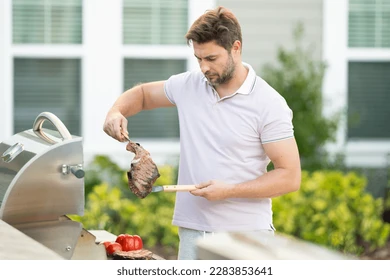

Result 2, Image Path = /content/spanish_clip_test_images/una_mujer_cocinando_empanadas.jpeg


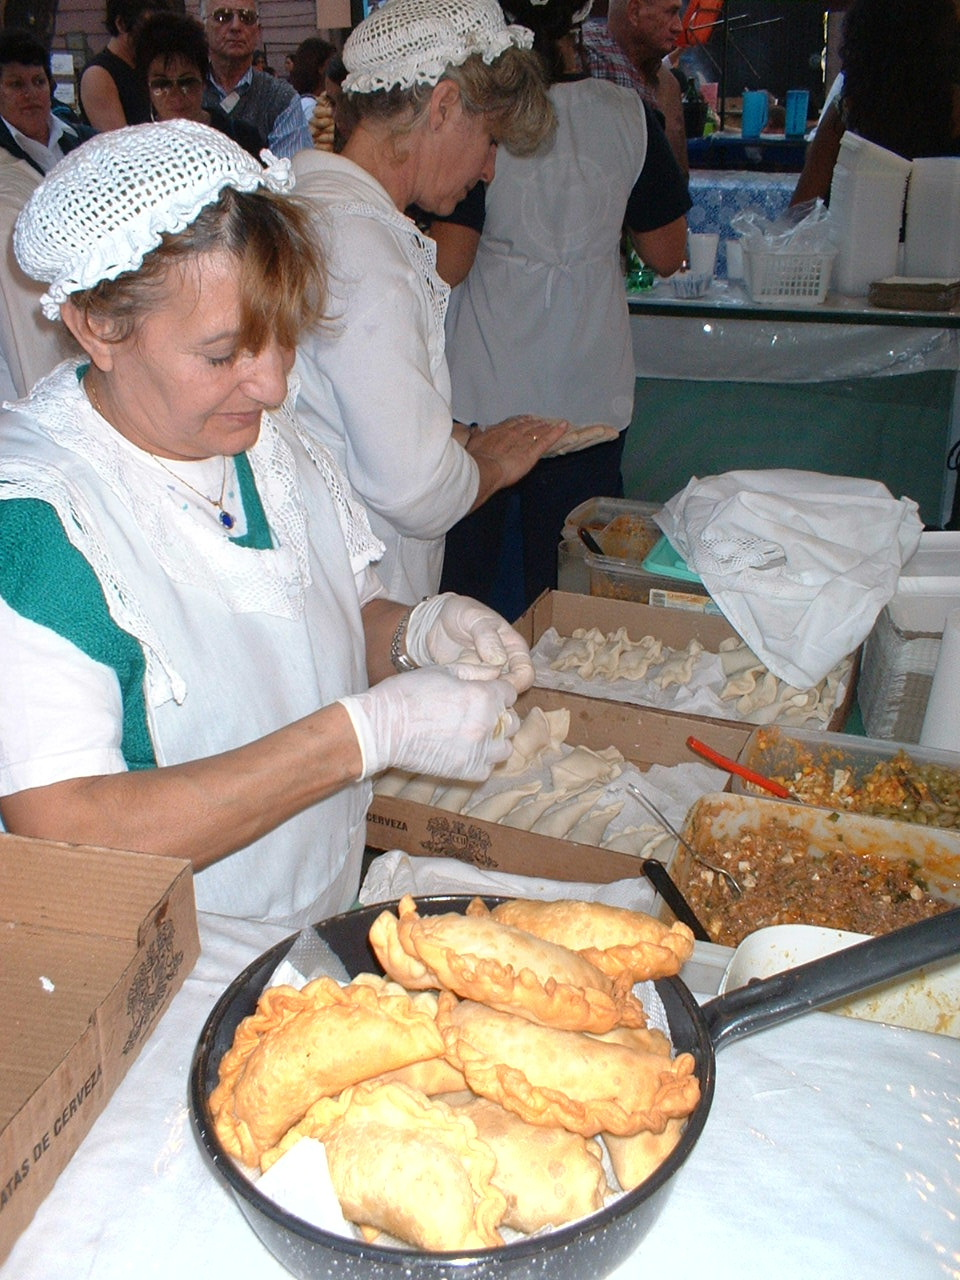

Result 3, Image Path = /content/spanish_clip_test_images/una_persona_comiendo_tacos.jpg


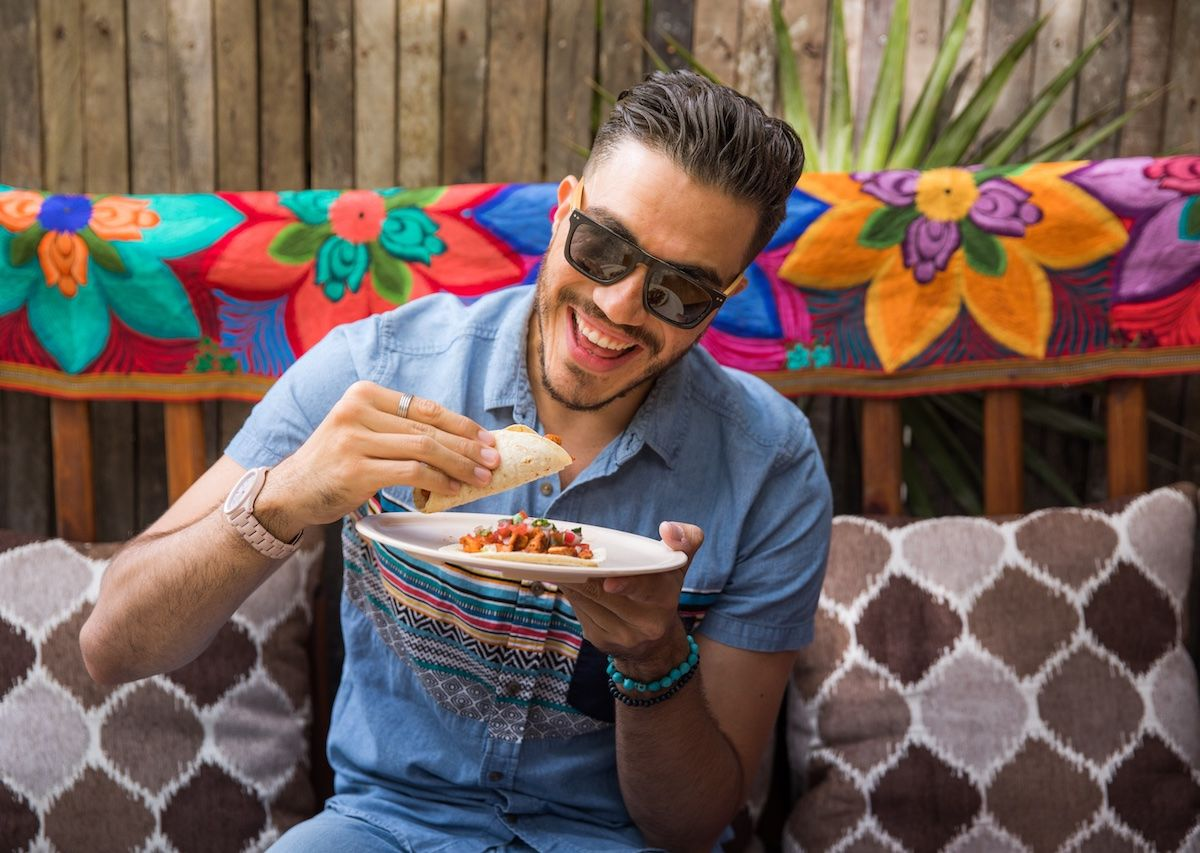

In [36]:
#used texts in this list to get the pictures:
test_sentences_ref = ["un plato de paella", "una persona comiendo tacos",
"un chef cortando verduras", "un hombre asando carne",
"una mesa llena de tapas", "una persona sirviendo churros",
"una pareja compartiendo vino", "una mujer cocinando empanadas",
"un hombre exprimiendo limones para ceviche", "una familia comiendo tamales",
"una persona sosteniendo una tortilla", "un chef preparando gazpacho",
"una mujer vendiendo frutas en un mercado","una persona revolviendo chocolate caliente",
"un grupo bailando flamenco", "un hombre tocando guitarra en la calle",
"una persona pintando un mural", "una multitud celebrando un festival",
"un avión despegando en el aeropuerto",
"un barco navegando en el océano",
"un coche rojo estacionado en la calle",
"una motocicleta pasando por un puente",
"un tren llegando a la estación",
"un helicóptero volando sobre la ciudad",
"un camión transportando cajas",
"un tractor trabajando en el campo",
"una bicicleta apoyada en una pared",
"un autobús amarillo en movimiento",
]


select_sentence = ""
qry_tokens = clip_tokenizer(text=select_sentence, padding='max_length', truncation=True,
                   max_length=77, return_tensors='pt').to(device)

qry_embeds = spanish_clip_test(qry_tokens['input_ids']).to(device)

results = collection.query(
    query_embeddings=qry_embeds.tolist(),
    n_results=3
)

# Print the results
print("Search results (most similar images):")
for i, (distance, document) in enumerate(zip(results['distances'][0], results['documents'][0])):
    print(f"Result {i+1}, Image Path = {document}")
    #display image
    img = Image.open(document)
    display(img)